# Importar librerías

In [122]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


# Librerías de simulación y análisis

In [123]:
import pandas as pd
pd.set_option('display.max_columns', 50)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

from src.simulacion_cumulo import (
    ClusterSimulationConfig,
    OpenClusterSimulator,
)
from src.vector_director import run_cluster_analysis_from_dataframe
from src.proper_motion_simulator import simulate_proper_motions_from_3d_velocity
from src.utils import (
    show_cluster_validation_products_icrs,
    correct_gaia_proper_motions,
    plot_pm_vectors_on_sky,
    galactic_lb_to_unit_vectors,
)

In [124]:
# antapex solar
l = 312.20
b = -23.70

coord_gal = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic')
coord_icrs = coord_gal.icrs

coord_icrs, coord_icrs.ra.deg, coord_icrs.dec.deg

(<SkyCoord (ICRS): (ra, dec) in deg
     (262.62894275, -80.95751184)>,
 262.6289427537442,
 -80.95751183776322)

In [125]:
# apex solar
l = 47.8
b = 23.7

coord_gal = SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic')
coord_icrs = coord_gal.icrs

coord_icrs, coord_icrs.ra.deg, coord_icrs.dec.deg

(<SkyCoord (ICRS): (ra, dec) in deg
     (267.04975046, 23.10315404)>,
 267.04975046036833,
 23.103154035627863)

In [126]:
from astropy.coordinates import SkyCoord
from astropy import units as u

# Punto 1
l1 = 312.20
b1 = -23.70

# Punto 2
l2 = 47.8
b2 = 23.7

coord1 = SkyCoord(l=l1*u.deg, b=b1*u.deg, frame="galactic")
coord2 = SkyCoord(l=l2*u.deg, b=b2*u.deg, frame="galactic")

sep = coord1.separation(coord2)

print(sep)
print(sep.deg)

104d05m09.85623553s
104.08607117653654


# Cargue de datos

In [127]:
cluster_real = pd.read_csv(r"C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\dev\pasantia\analisis_detallado_hyades.csv")

In [128]:
cluster_real = correct_gaia_proper_motions(
    cluster_real,
    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",
    pmra_col="pmra",
    pmdec_col="pmdec",
    correct_solar_reflex=True
)

In [129]:
import astropy.units as u
from astropy.coordinates import SkyCoord

coord_gal = SkyCoord(l=177.565674*u.deg, b=-25.7529*u.deg, frame='galactic')
coord_icrs = coord_gal.icrs

In [130]:
coord_icrs

<SkyCoord (ICRS): (ra, dec) in deg
    (62.49044917, 15.41692508)>

In [131]:
cluster_real

,Unnamed: 0,source_id,ra,dec,parallax,pmra,pmdec,ruwe,phot_g_mean_mag,bp_rp,radial_velocity,ra_error,dec_error,pmra_error,pmdec_error,parallax_error,visibility_periods_used,phot_bp_mean_mag,phot_rp_mean_mag,nu_eff_used_in_astrometry,pseudocolour,ecl_lat,astrometric_params_solved,zp,parallax_corrected,...,ConteoAgrupaciones,PresenteEnMuestras,iteraciones,grupo,coordenada_ra,coordenada_dec,division,distance_pc,numeracion,cluster_id,probabilidad,parallax_corr,l_deg,b_deg,pm_l_cosb,pm_b,mu_l_solar_reflex,mu_b_solar_reflex,pm_l_cosb_corr,pm_b_corr,pmra_corr,pmdec_corr,d_pmra_corr,d_pmdec_corr,pm_corr_valid
0,1628264,45198178534988672,62.490400,15.416884,21.226790,118.522696,-21.854283,1.516279,14.580980,3.142399,48.148090,0.037609,0.025730,0.053280,0.038144,0.041074,15,16.436302,13.293903,1.229845,NaN,-5.520582,31,-0.061362,21.226852,...,320,320,40,0,60,-30,60_-30,47.110143,8,0_8,1.000000,21.226852,177.565674,-25.752963,94.464023,74.845089,56.869865,-8.674732,37.594158,83.519822,87.621963,26.669703,-30.900733,48.523986,True
1,1628267,45293526808851200,62.865737,15.992065,20.975848,117.535943,-19.692321,1.130458,13.776278,2.822394,NaN,0.016124,0.011781,0.020604,0.016645,0.017986,16,15.372004,12.549610,1.254701,NaN,-5.021401,31,-0.056480,20.975904,...,311,311,40,0,60,-30,60_-30,47.673749,8,0_8,1.000000,20.975904,177.349485,-25.102372,92.175360,75.539317,56.373617,-9.298317,35.801743,84.837635,87.438735,28.873114,-30.097208,48.565435,True
2,1628297,45845378567048320,64.006596,16.982964,21.622122,117.389516,-29.940662,1.218000,13.754810,2.825718,NaN,0.019738,0.013047,0.026361,0.018357,0.020970,16,15.356439,12.530721,1.255523,NaN,-4.241645,31,-0.056360,21.622178,...,318,318,40,0,60,-30,60_-30,46.248810,8,0_8,1.000000,21.622178,177.316388,-23.626684,99.422205,69.224033,58.138219,-11.075588,41.283986,80.299621,87.746102,21.284226,-29.643414,51.224888,True
3,1629424,47620265212420096,64.508186,18.256666,21.569793,113.307985,-31.327170,1.935553,7.371560,0.841778,NaN,0.039608,0.023747,0.050349,0.036436,0.042027,14,7.707087,6.865309,1.551724,NaN,-3.069937,31,-0.035859,21.569829,...,311,311,40,0,60,-30,60_-30,46.361054,8,0_8,1.000000,21.569829,176.610551,-22.431317,97.943077,65.017264,58.582438,-12.510616,39.360639,77.527880,84.345826,21.109563,-28.962158,52.436733,True
4,1629644,48455894049191424,63.624805,18.729881,20.680377,110.101280,-30.568058,3.769246,13.204377,2.762054,33.215150,0.058516,0.035605,0.073233,0.050972,0.062001,15,14.757710,11.995655,1.260693,NaN,-2.458051,31,-0.055357,20.680432,...,310,310,40,0,60,-30,60_-30,48.354889,8,0_8,1.000000,20.680432,175.626652,-22.748441,95.985928,61.995158,56.934452,-12.072145,39.051476,74.067303,81.305639,20.009403,-28.795641,50.577461,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,2195024,3411811317161811328,72.569882,20.625627,22.051541,89.481733,-44.390825,1.256963,13.134485,2.683378,NaN,0.016993,0.007652,0.025301,0.015853,0.018649,18,14.623905,11.940527,1.266831,NaN,-1.833424,31,-0.054312,22.051596,...,318,318,40,0,60,-30,60_-30,45.348193,8,0_8,1.000000,22.051596,179.735935,-15.039595,89.516373,44.320930,57.175083,-19.239888,32.341290,63.560818,70.165229,12.758419,-19.316504,57.149244,True
451,2196160,3409548556593300480,69.937873,18.094693,22.314480,102.884844,-34.193192,1.081794,16.200205,3.600326,NaN,0.052094,0.028404,0.068084,0.046308,0.056411,19,18.425732,14.825406,1.195514,NaN,-4.025621,31,-0.057638,22.314537,...,314,314,40,0,60,-30,60_-30,44.813835,8,0_8,1.000000,22.314537,180.244980,-18.551420,90.286346,60.023672,57.392703,-15.652208,32.893643,75.675880,79.884925,20.669525,-22.999919,54.862717,True
452,2196198,3410559832411244160,69.965462,19.659390,23.499067,87.291986,-34.152279,16.270372,14.677451,3.234291,63.732940,0.445637,0.233465,0.564939,0.360803,0.469986,15,16.545061,13.310770,1.221697,NaN,-2.479153,31,-0.063

# Configuración de simulaciones

## Configuración de sintéticas

In [132]:
#configuracion para generar cúmulo sintético de las hyades
config_hyades = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,
)

config_hyades_solar = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=227.79628626384542, 
    apex_dec_deg=-23.69031810716205,

    speed_kms=25.0,
    seed=42,
)

config_hyades_error_parallax = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    parallax_error_mas=0.03,
)

config_hyades_error_pmra = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
)

config_hyades_error_pmdec = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmdec_error_masyr=0.03,
)

config_hyades_error_pm = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
    pmdec_error_masyr=0.03,
)

config_hyades_error_all = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
    pmdec_error_masyr=0.03,
    parallax_error_mas=0.03,
)

config_hyades_error_dispersion = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    speed_sigma_kms=5
)

config_hyades_error_alld = ClusterSimulationConfig(
    n_members=455,

    # Centro en ecuatoriales
    center_ra_deg=67.0,
    center_dec_deg=17.0,

    distance_pc=85.0,
    radius_pc=5.0,

    # Ápex en ecuatoriales
    apex_ra_deg=97.89,
    apex_dec_deg=6.62,

    speed_kms=25.0,
    seed=42,

    # Inclusión de errores
    pmra_error_masyr=0.03,
    pmdec_error_masyr=0.03,
    parallax_error_mas=0.03,

    # Inclusión de errores
    speed_sigma_kms=5
)


## generación de simulaciones sintéticas

In [133]:
# ejecución de simulación del cúmulo sintético de las hyades
simulator_hyades = OpenClusterSimulator(config_hyades)
simulator_hyades_solar = OpenClusterSimulator(config_hyades_solar)
simulator_hyades_error_parallax = OpenClusterSimulator(config_hyades_error_parallax)
simulator_hyades_error_pmra = OpenClusterSimulator(config_hyades_error_pmra)
simulator_hyades_error_pmdec = OpenClusterSimulator(config_hyades_error_pmdec)
simulator_hyades_error_pm = OpenClusterSimulator(config_hyades_error_pm)
simulator_hyades_error_all = OpenClusterSimulator(config_hyades_error_all)
simulator_hyades_error_dispersion = OpenClusterSimulator(config_hyades_error_dispersion)
simulator_hyades_error_alld = OpenClusterSimulator(config_hyades_error_alld)

hyades_sintetico = simulator_hyades.simulate()
hyades_sintetico["cluster_id"] ="0_8"
hyades_sintetico["grupo"] = "1"

hyades_sintetico_solar = simulator_hyades_solar.simulate()
hyades_sintetico_solar["cluster_id"] ="0_8"
hyades_sintetico_solar["grupo"] = "1"

hyades_sintetico_error_parallax = simulator_hyades_error_parallax.simulate()
hyades_sintetico_error_parallax["cluster_id"] ="0_8"
hyades_sintetico_error_parallax["grupo"] = "1"

hyades_sintetico_error_pmra = simulator_hyades_error_pmra.simulate()
hyades_sintetico_error_pmra["cluster_id"] ="0_8"
hyades_sintetico_error_pmra["grupo"] = "1"

hyades_sintetico_error_pmdec = simulator_hyades_error_pmdec.simulate()
hyades_sintetico_error_pmdec["cluster_id"] ="0_8"
hyades_sintetico_error_pmdec["grupo"] = "1"

hyades_sintetico_error_pm = simulator_hyades_error_pm.simulate()
hyades_sintetico_error_pm["cluster_id"] ="0_8"
hyades_sintetico_error_pm["grupo"] = "1"

hyades_sintetico_error_all = simulator_hyades_error_all.simulate()
hyades_sintetico_error_all["cluster_id"] ="0_8"
hyades_sintetico_error_all["grupo"] = "1"

hyades_sintetico_error_dispersion = simulator_hyades_error_dispersion.simulate()
hyades_sintetico_error_dispersion["cluster_id"] ="0_8"
hyades_sintetico_error_dispersion["grupo"] = "1"

hyades_sintetico_error_alld = simulator_hyades_error_alld.simulate()
hyades_sintetico_error_alld["cluster_id"] ="0_8"
hyades_sintetico_error_alld["grupo"] = "1"

## Generación de simulaciones semi-sintéticas

In [134]:
# Simulacion con valores reportados de velocidad
simulado_uvw = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    # Velocidad galáctica heliocéntrica U,V,W
    # u_kms=-41.92,
    # v_kms=-19.35,
    # w_kms=-1.11,
    apex_ra_deg=227.79628626384542, 
    apex_dec_deg=-23.69031810716205,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)
# Simulacion con el valor de apex del cumulo
simulado_apex = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=97.89,
    apex_dec_deg=6.61,
    speed_kms=np.sqrt(41.92**2 + 19.35**2 + 1.11**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)
simulado_uvw_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    # Velocidad galáctica heliocéntrica U,V,W
    # u_kms=11.1,
    # v_kms=12.24,
    # w_kms=7.25,
    apex_ra_deg=227.79628626384542, 
    apex_dec_deg=-23.69031810716205,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),
    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax_corrected",

    apply_pmra_error=False,
    apply_pmdec_error=False,
    apply_parallax_error=False,

    seed=42,
)
# Simulacion con el valor de apex del cumulo
simulado_apex_solar = simulate_proper_motions_from_3d_velocity(
    df=cluster_real,

    apex_ra_deg=227.79628626384542, 
    apex_dec_deg=-23.69031810716205,
    speed_kms=np.sqrt(11.1**2 + 12.24**2 + 7.25**2),

    ra_col="ra",
    dec_col="dec",
    parallax_col="parallax",

    apply_pmra_error=True,
    apply_pmdec_error=True,
    apply_parallax_error=False,

    seed=42,
)

In [135]:
simulado_uvw[["apex_ra_deg","apex_dec_deg"]].describe()

,apex_ra_deg,apex_dec_deg
count,4.550000e+02,4.550000e+02
mean,2.277963e+02,-2.369032e+01
std,2.361598e-12,2.133975e-13
min,2.277963e+02,-2.369032e+01
25%,2.277963e+02,-2.369032e+01
50%,2.277963e+02,-2.369032e+01
75%,2.277963e+02,-2.369032e+01
max,2.277963e+02,-2.369032e+01


## generación de análisis sintéticos

In [136]:
# ejecucion de cálculo de ápex para cúmulo sintético
result_hyades_sintetico = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_solar = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_parallax = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_parallax,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmra = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmra,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_pmdec = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pmdec,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

result_hyades_sintetico_error_pm = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_pm,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_all = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_all,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_dispersion = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_dispersion,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_sintetico_error_alld = run_cluster_analysis_from_dataframe(
    df = hyades_sintetico_error_alld,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

## Generación de resultados semi-sintéticos

In [137]:
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad = run_cluster_analysis_from_dataframe(
    df = simulado_uvw,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex = run_cluster_analysis_from_dataframe(
    df = simulado_apex,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_velocidad_solar = run_cluster_analysis_from_dataframe(
    df = simulado_uvw_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion de cálculo de ápex para cúmulo sintético_solar
result_hyades_semisintetico_apex_solar = run_cluster_analysis_from_dataframe(
    df = simulado_apex_solar,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion sobre caso clásico hyades
result_hyades_classic = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra",
    pmdec_col = "pmdec",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecucion sobre caso clásico hyades
result_hyades_classic_corrected = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "pmra_corr",
    pmdec_col = "pmdec_corr",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)
# ejecución sobre caso corregido hyades solar
result_hyades_classic_solar = run_cluster_analysis_from_dataframe(
    df = cluster_real,
    cluster_id = "0_8",
    group_col = "grupo",
    ra_col = "ra",
    dec_col = "dec",
    pmra_col = "d_pmra_corr",
    pmdec_col = "d_pmdec_corr",
    parallax_col = "parallax_corrected",
    cluster_col = "cluster_id",
    weight_fill_value =  1,
)

# Análisis de resultados

## Agrupación de resultados

In [138]:
all_results = {
    "Hy_s": result_hyades_sintetico["summary"],
    "Hy_s solar": result_hyades_sintetico_solar["summary"],
    "Hy_s err plx": result_hyades_sintetico_error_parallax["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err pmdec": result_hyades_sintetico_error_pmdec["summary"],
    "Hy_s err pm": result_hyades_sintetico_error_pm["summary"],
    "Hy_s err all": result_hyades_sintetico_error_all["summary"],
    "Hy_s err dispersion": result_hyades_sintetico_error_dispersion["summary"],
    "Hy_s err pmra": result_hyades_sintetico_error_pmra["summary"],
    "Hy_s err alld": result_hyades_sintetico_error_alld["summary"],
    "Hy_ss vel": result_hyades_semisintetico_velocidad["summary"],
    "Hy_ss apex": result_hyades_semisintetico_apex["summary"], 
    "Hy_ss vel solar": result_hyades_semisintetico_velocidad_solar["summary"],
    "Hy_ss apex solar": result_hyades_semisintetico_apex_solar["summary"],
    "Hy_ss classic": result_hyades_classic["summary"],
    "Hy_ss classic corrected": result_hyades_classic_corrected["summary"],
    "Hy_ss classic solar": result_hyades_classic_solar["summary"],
}

In [139]:
df_results = pd.DataFrame(
    [
        {
            "type": result_name,
            **result_dict,
        }
        for result_name, result_dict in all_results.items()
    ]
)

df_results

,type,cluster_id,n_stars,n_stars_initial,n_stars_refined,apex_initial_ra_deg,apex_initial_dec_deg,antapex_initial_ra_deg,antapex_initial_dec_deg,rms_pole_residual_initial_deg,median_pole_residual_initial_deg,toward_apex_fraction_initial,apex_refined_ra_deg,apex_refined_dec_deg,antapex_refined_ra_deg,antapex_refined_dec_deg,rms_pole_residual_refined_deg,median_pole_residual_refined_deg,toward_apex_fraction_refined,cross_initial_apex_ra_deg,cross_initial_apex_dec_deg,cross_initial_rms_residual_deg,cross_initial_n_pairs_used,cross_refined_apex_ra_deg,cross_refined_apex_dec_deg,cross_refined_rms_residual_deg,cross_refined_n_pairs_used
0,Hy_s,0_8,455,455,455,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890008,6.619998,0.001374,103285,97.890008,6.619998,0.001374,103285
1,Hy_s solar,0_8,455,455,455,227.796286,-23.690318,47.796286,23.690318,3.741152e-08,2.717284e-08,1.0,227.796286,-23.690318,47.796286,23.690318,3.741152e-08,2.717284e-08,1.0,227.796287,-23.690318,0.000156,103285,227.796287,-23.690318,0.000156,103285
2,Hy_s err plx,0_8,455,455,455,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890002,6.620000,277.890002,-6.620000,8.611562e-08,6.711985e-08,1.0,97.890008,6.619998,0.001374,103285,97.890008,6.619998,0.001374,103285
3,Hy_s err pmra,0_8,455,455,455,97.892069,6.619370,277.892069,-6.619370,7.248040e-03,4.909112e-03,1.0,97.892069,6.619370,277.892069,-6.619370,7.248040e-03,4.909112e-03,1.0,97.881281,6.623834,3.303883,103285,97.881281,6.623834,3.303883,103285
4,Hy_s err pmdec,0_8,455,455,455,97.885905,6.622271,277.885905,-6.622271,2.610551e-02,1.786115e-02,1.0,97.885905,6.622271,277.885905,-6.622271,2.610551e-02,1.786115e-02,1.0,97.876894,6.624614,6.158009,103285,97.876894,6.624614,6.158009,103285
5,Hy_s err pm,0_8,455,455,455,97.871318,6.625765,277.871318,-6.625765,2.640652e-02,1.679867e-02,1.0,97.871318,6.625765,277.871318,-6.625765,2.640652e-02,1.679867e-02,1.0,97.886287,6.619485,6.302658,103285,97.886287,6.619485,6.302658,103285
6,Hy_s err all,0_8,455,455,455,97.860903,6.631378,277.860903,-6.631378,2.787582e-02,1.894264e-02,1.0,97.860903,6.631378,277.860903,-6.631378,2.787582e-02,1.894264e-02,1.0,97.852611,6.634088,6.530617,103285,97.852611,6.634088,6.530617,103285
7,Hy_s err dispersion,0_8,455,455,455,97.890002,6.620000,277.890002,-6.620000,1.737707e-07,1.087449e-07,1.0,97.890002,6.620000,277.890002,-6.620000,1.737707e-07,1.087449e-07,1.0,97.889994,6.620004,0.002943,103285,97.889994,6.620004,0.002943,103285
8,Hy_s err alld,0_8,455,455,455,97.853798,6.633850,277.853798,-6.633850,3.112349e-02,1.918742e-02,1.0,97.853798,6.633850,277.853798,-6.633850,3.112349e-02,1.918742e-02,1.0,97.837175,6.640831,6.718820,103285,97.837175,6.640831,6.718820,103285
9,Hy_ss vel,0_8,455,455,455,227.796286,-23.690318,47.796286,23.690318,9.249275e-08,5.666736e-08,1.0,227.796286,-23.690318,47.796286,23.690318,9.249275e-08,5.666736e-08,1.0,227.796287,-23.690317,0.000231,79800,227.796287,-23.690317,0.000231,79800


In [140]:
result_hyades_classic_solar["summary"]

{'cluster_id': '0_8',
 'n_stars': 455,
 'n_stars_initial': 455,
 'n_stars_refined': 455,
 'apex_initial_ra_deg': 267.05828372026485,
 'apex_initial_dec_deg': 23.096546001240593,
 'antapex_initial_ra_deg': 87.05828372026484,
 'antapex_initial_dec_deg': -23.096546001240593,
 'rms_pole_residual_initial_deg': 3.7898033159623465e-07,
 'median_pole_residual_initial_deg': 2.5526680870772355e-07,
 'toward_apex_fraction_initial': 1.0,
 'apex_refined_ra_deg': 267.05828372026485,
 'apex_refined_dec_deg': 23.096546001240593,
 'antapex_refined_ra_deg': 87.05828372026484,
 'antapex_refined_dec_deg': -23.096546001240593,
 'rms_pole_residual_refined_deg': 3.7898033159623465e-07,
 'median_pole_residual_refined_deg': 2.5526680870772355e-07,
 'toward_apex_fraction_refined': 1.0,
 'cross_initial_apex_ra_deg': 267.05824948893047,
 'cross_initial_apex_dec_deg': 23.09648162404009,
 'cross_initial_rms_residual_deg': 0.025548785492166885,
 'cross_initial_n_pairs_used': 79800,
 'cross_refined_apex_ra_deg': 267.


CLUSTER VALIDATION SUMMARY — ICRS / Gaia


,value
cluster_id,0_8
n_stars,455
n_stars_refined,455
fraction_kept,1.0
apex_ra_deg,227.796286
apex_dec_deg,-23.690318
antapex_ra_deg,47.796286
antapex_dec_deg,23.690318
rms_pole_residual_deg,0.0
median_pole_residual_deg,0.0



INTERPRETATION FLAGS
RMS pole residual          : 0.0000 deg
Median pole residual       : 0.0000 deg
Toward-apex fraction       : 1.0000
Fraction kept after filter : 1.0000
Apex-cross separation      : 0.0000 deg
Pole residuals             : GOOD, strong common-motion geometry.
Motion orientation         : GOOD, most stars move toward the recovered apex.
Apex estimator agreement   : GOOD, eigen and pole-cross estimators agree.


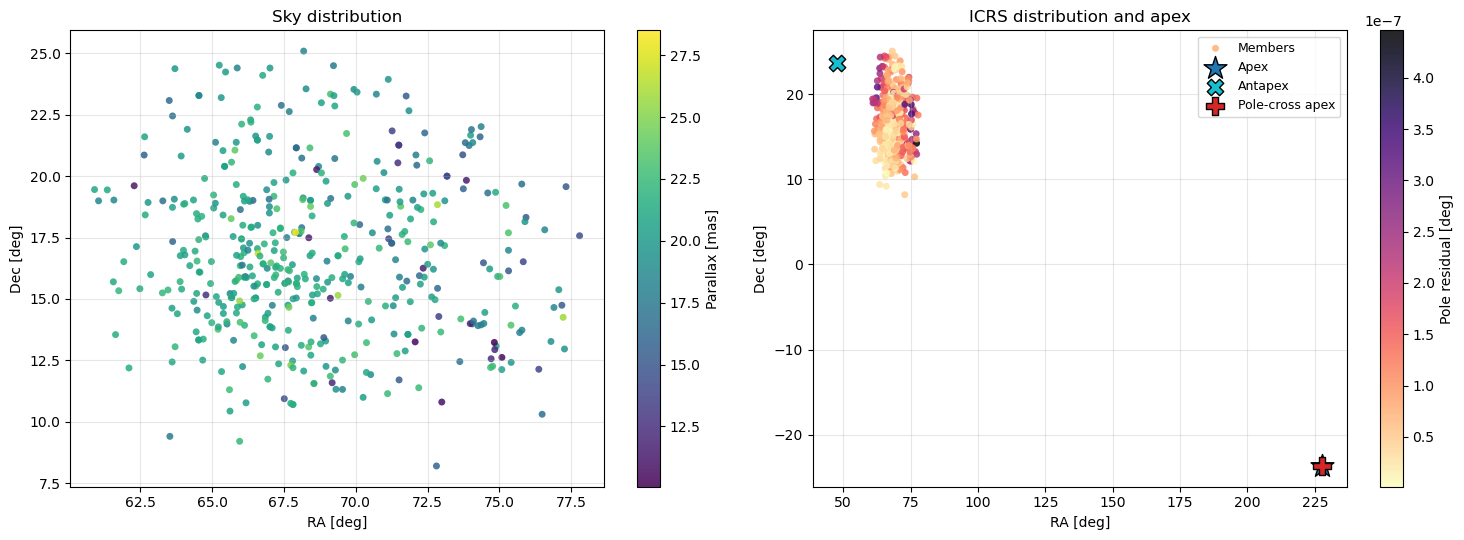

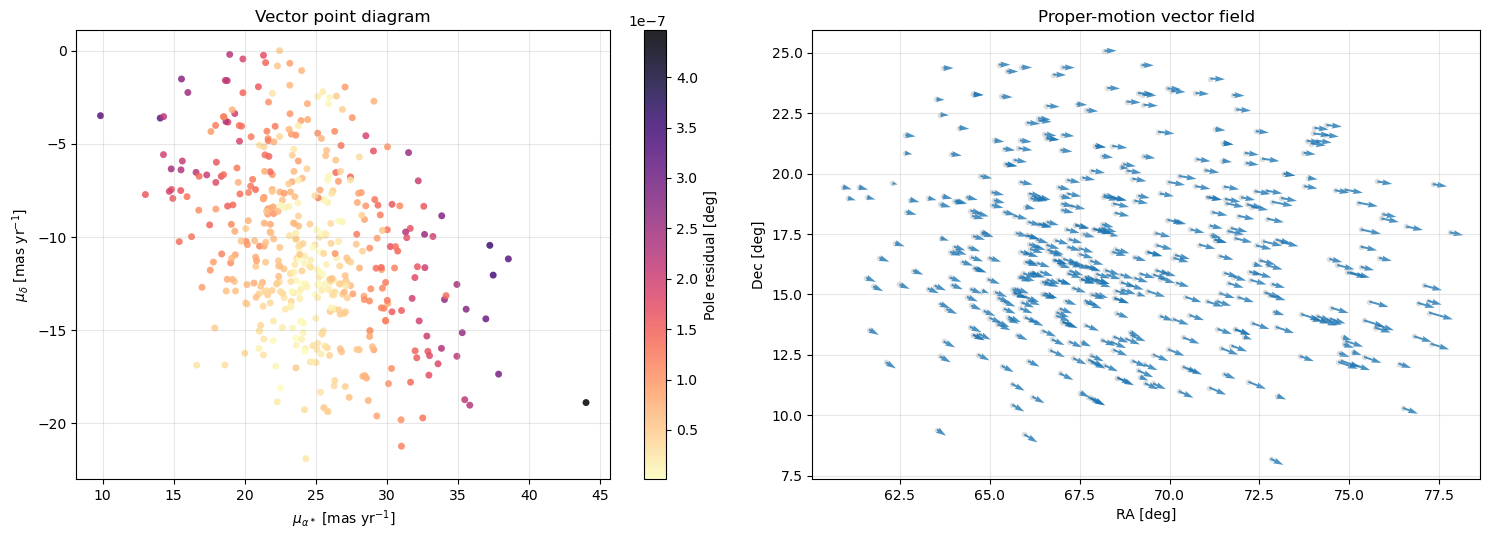

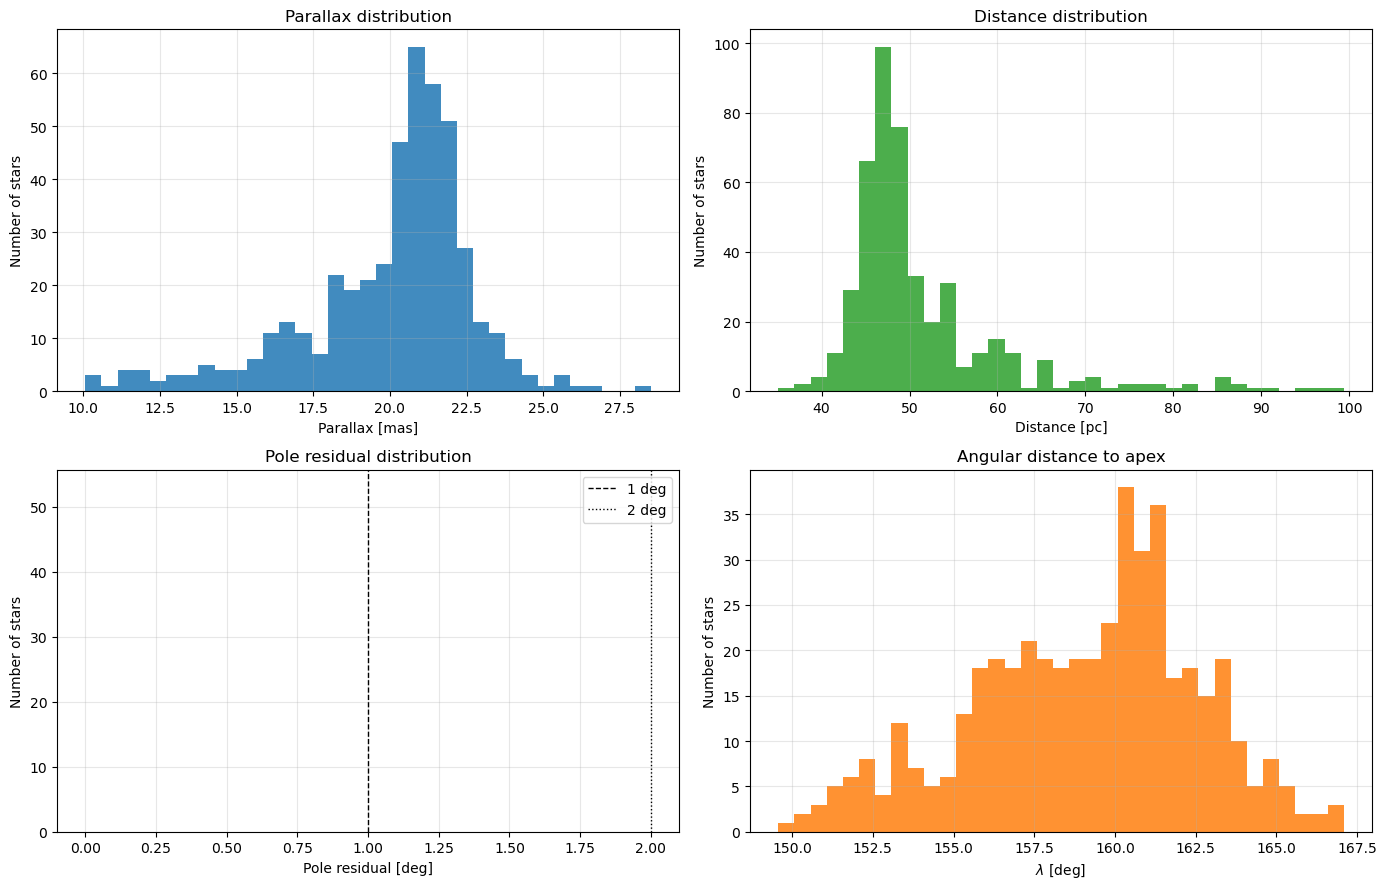

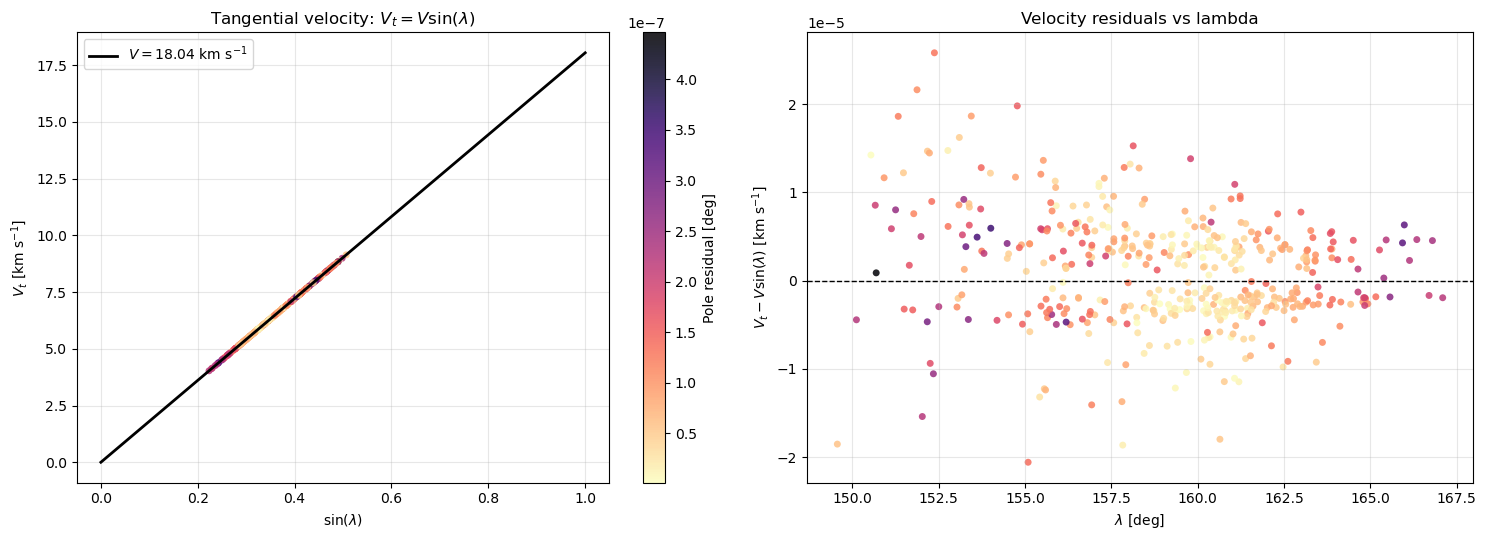

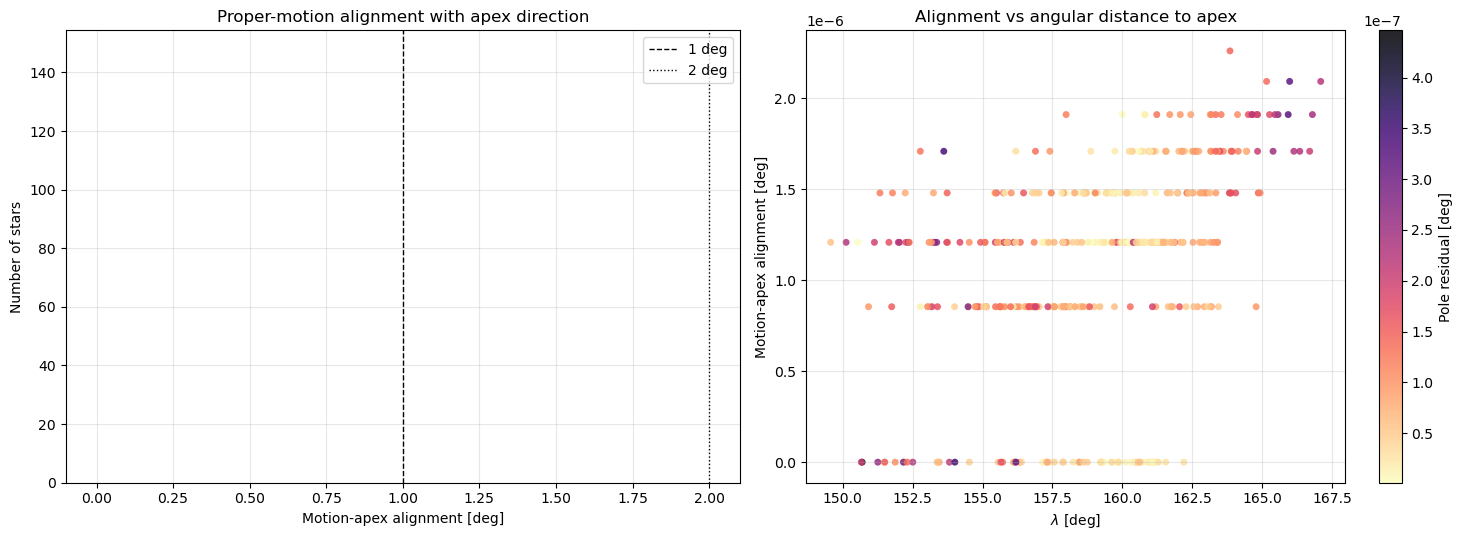

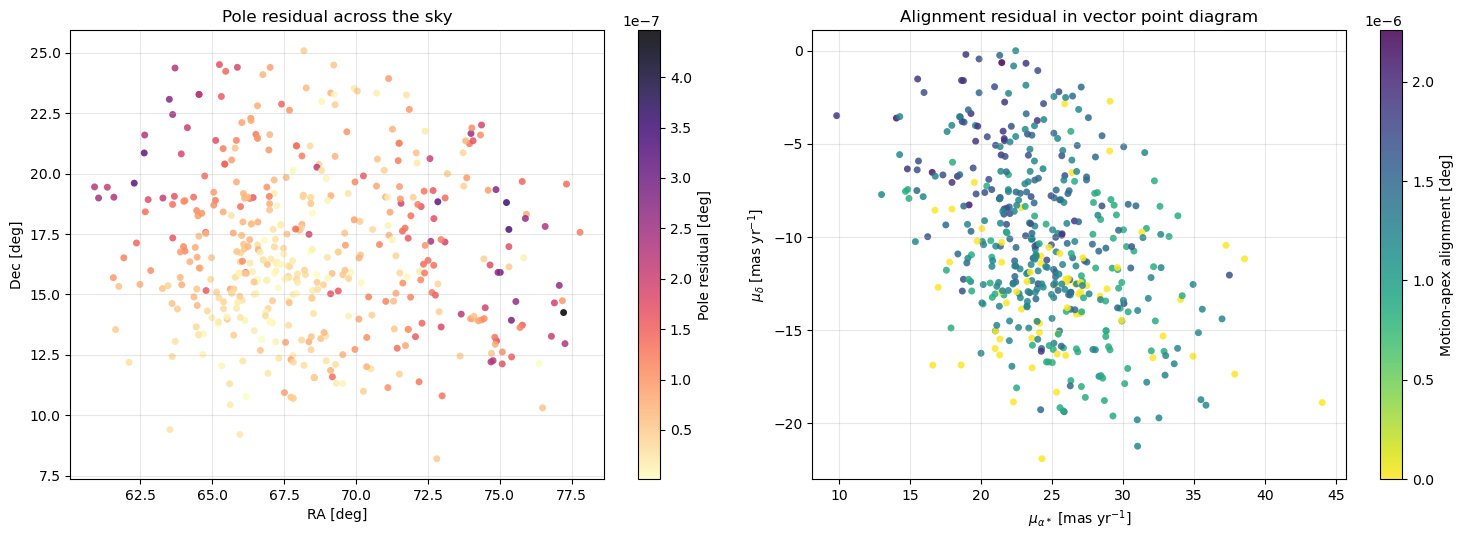

C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\src\utils.py:2451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


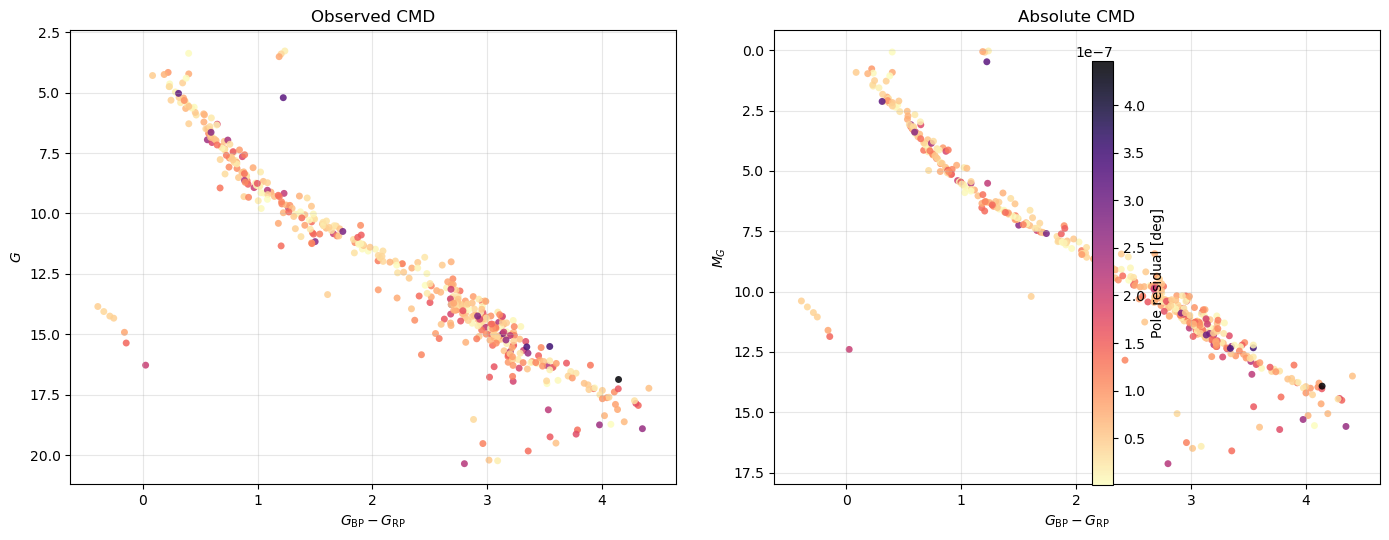


Returned objects
summary_df : global validation metrics
df_diag    : star-by-star diagnostic table
boot_df    : bootstrap apex table


In [141]:
summary_df, df_diag, boot_df = show_cluster_validation_products_icrs(
    result_hyades_semisintetico_velocidad_solar["cluster_result"],
    bootstrap_n=500,
)


CLUSTER VALIDATION SUMMARY — ICRS / Gaia


,value
cluster_id,0_8
n_stars,455
n_stars_refined,455
fraction_kept,1.0
apex_ra_deg,228.027016
apex_dec_deg,-23.648241
antapex_ra_deg,48.027016
antapex_dec_deg,23.648241
rms_pole_residual_deg,0.151907
median_pole_residual_deg,0.061859



INTERPRETATION FLAGS
RMS pole residual          : 0.1519 deg
Median pole residual       : 0.0619 deg
Toward-apex fraction       : 1.0000
Fraction kept after filter : 1.0000
Apex-cross separation      : 0.0247 deg
Pole residuals             : GOOD, strong common-motion geometry.
Motion orientation         : GOOD, most stars move toward the recovered apex.
Apex estimator agreement   : GOOD, eigen and pole-cross estimators agree.


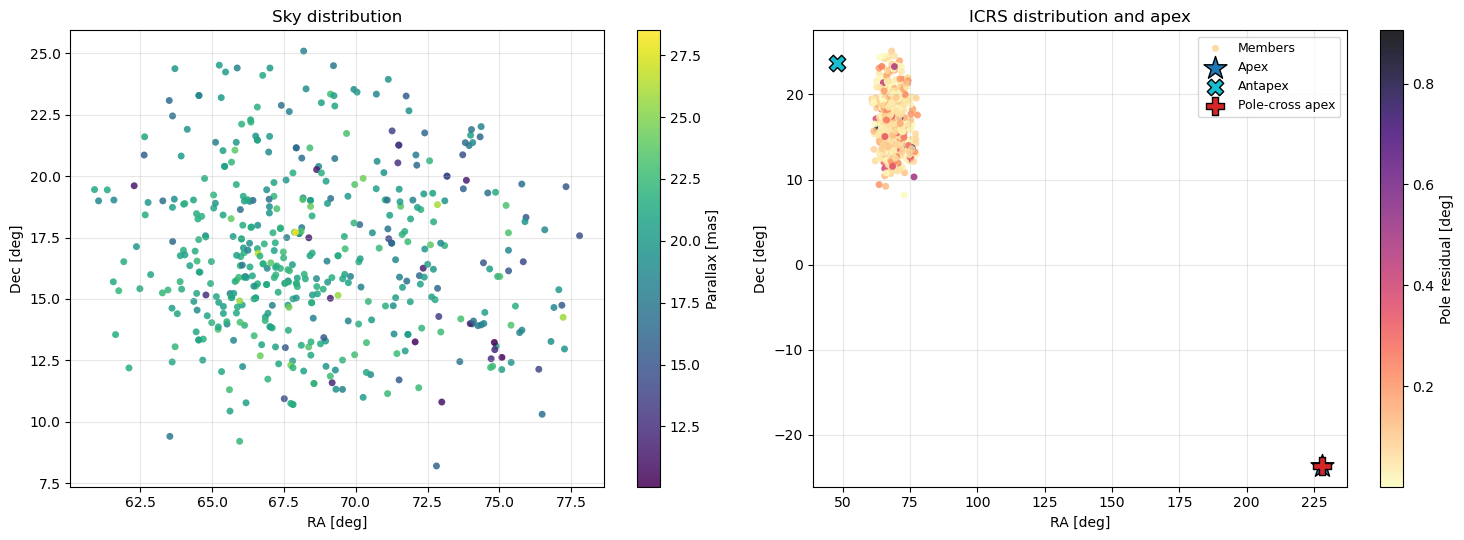

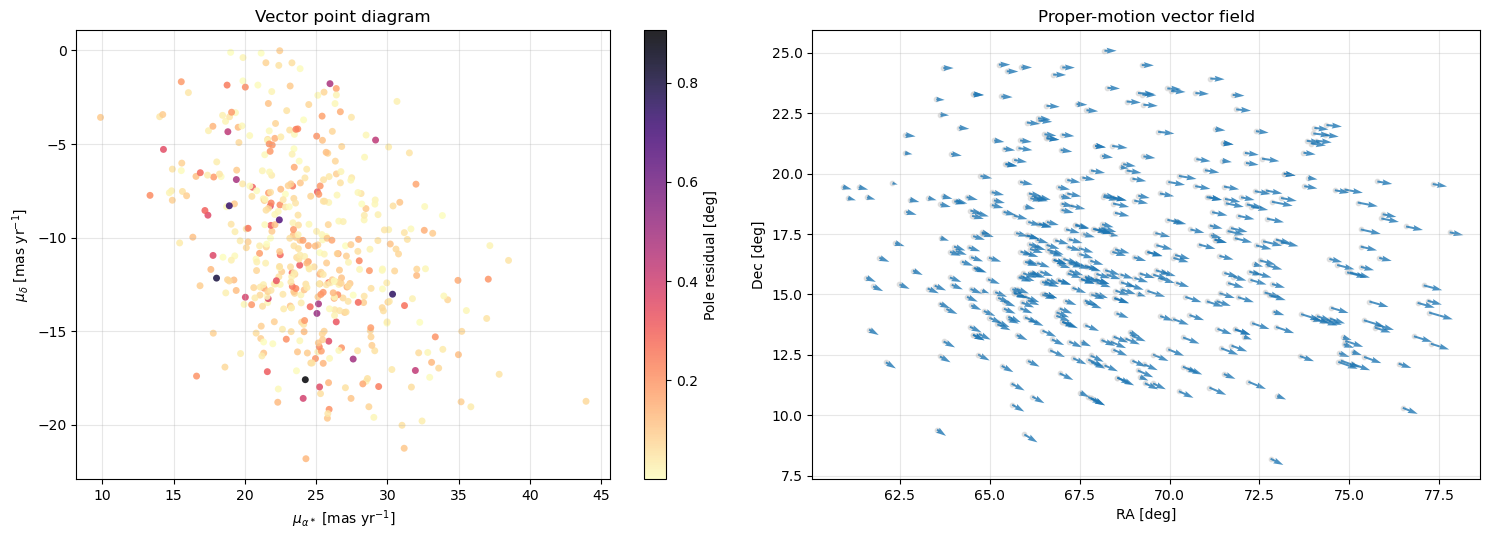

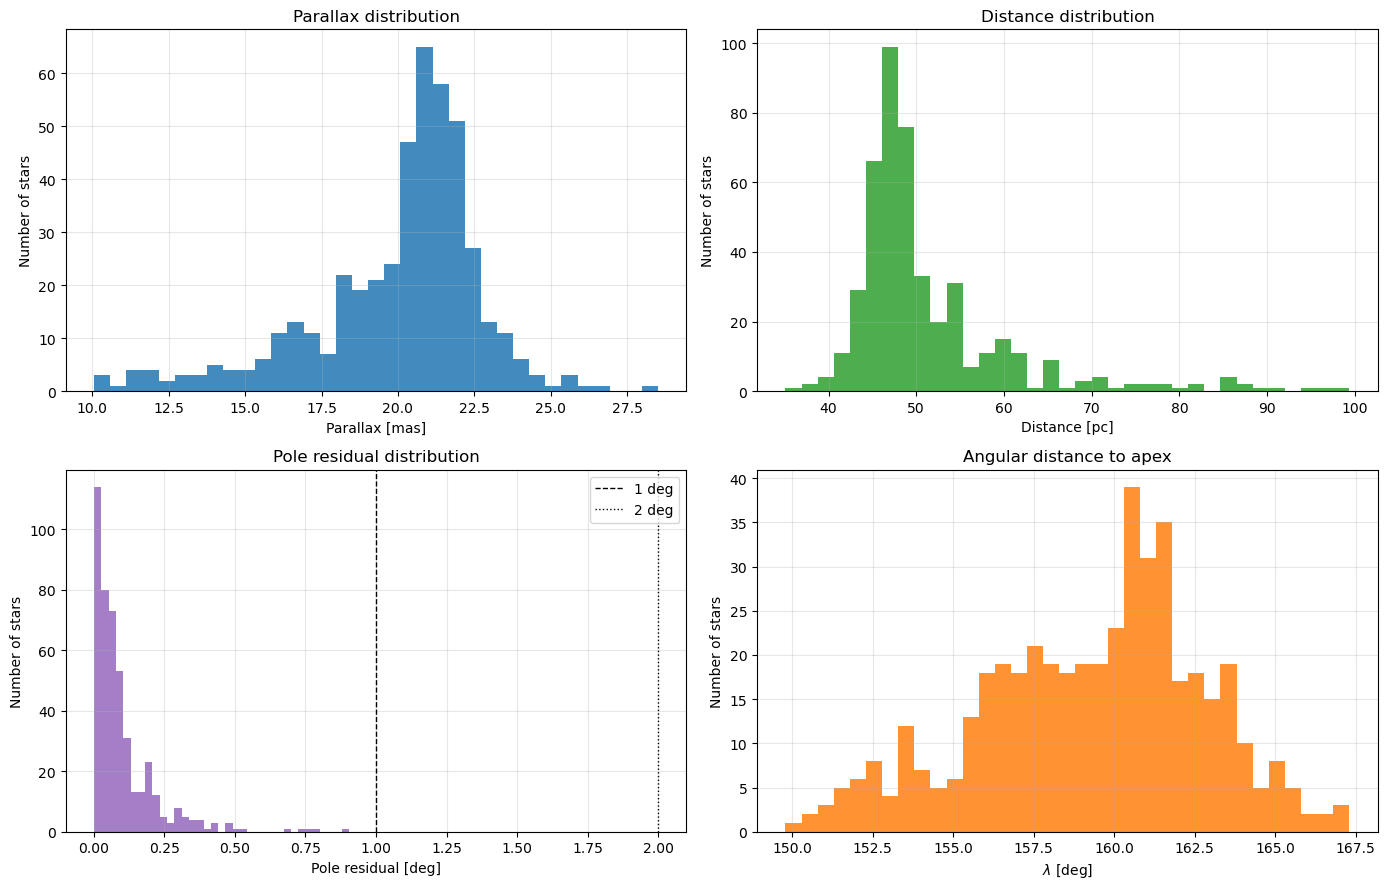

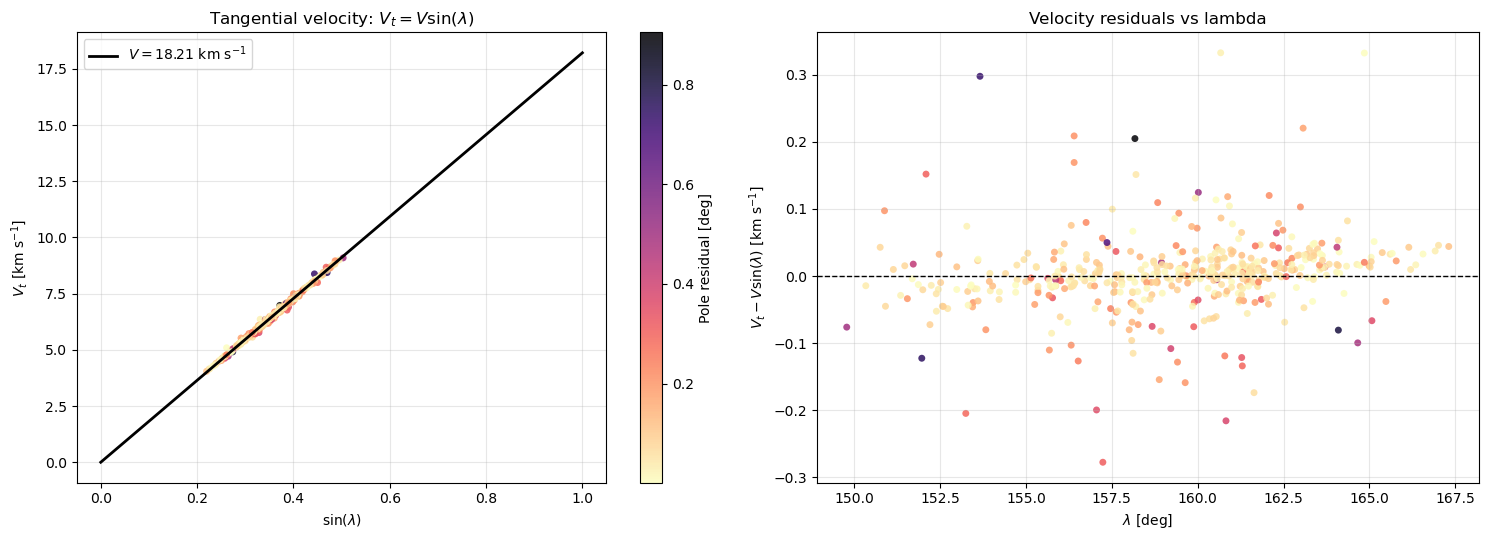

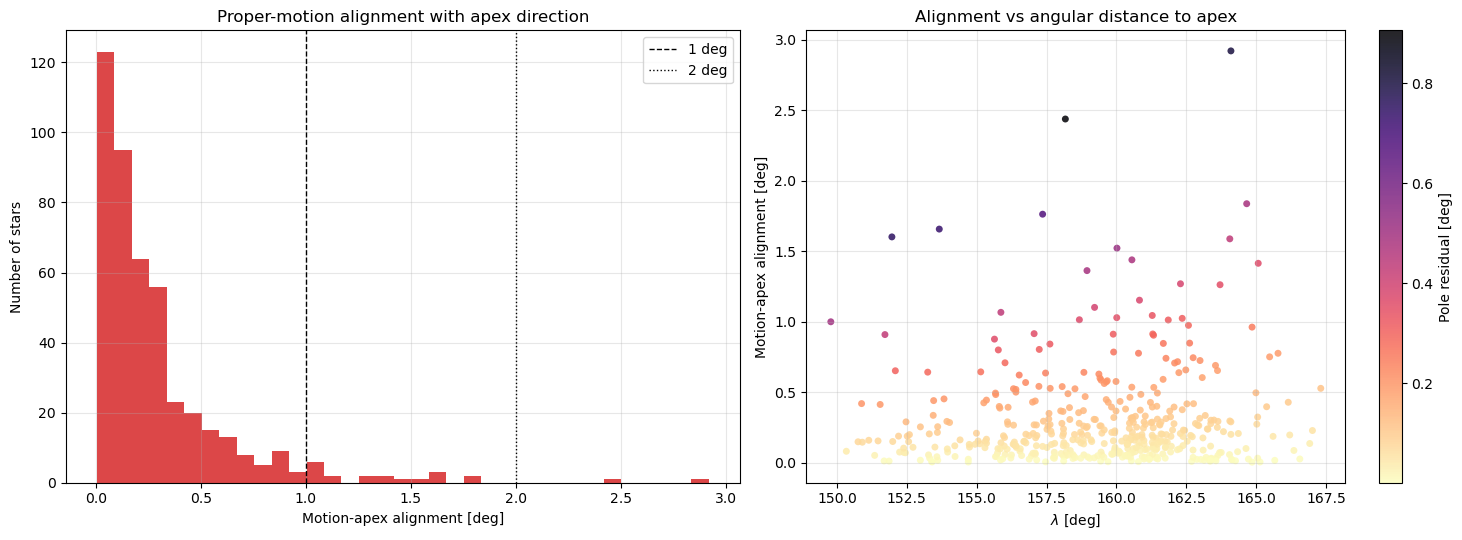

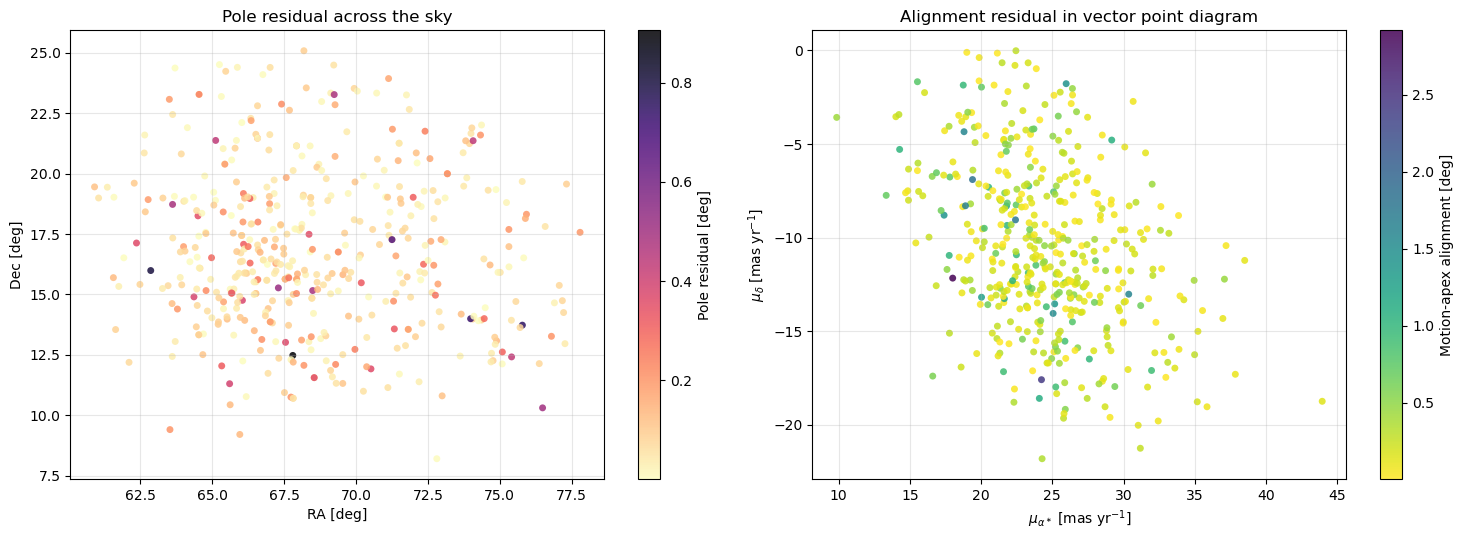

C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project\src\utils.py:2451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


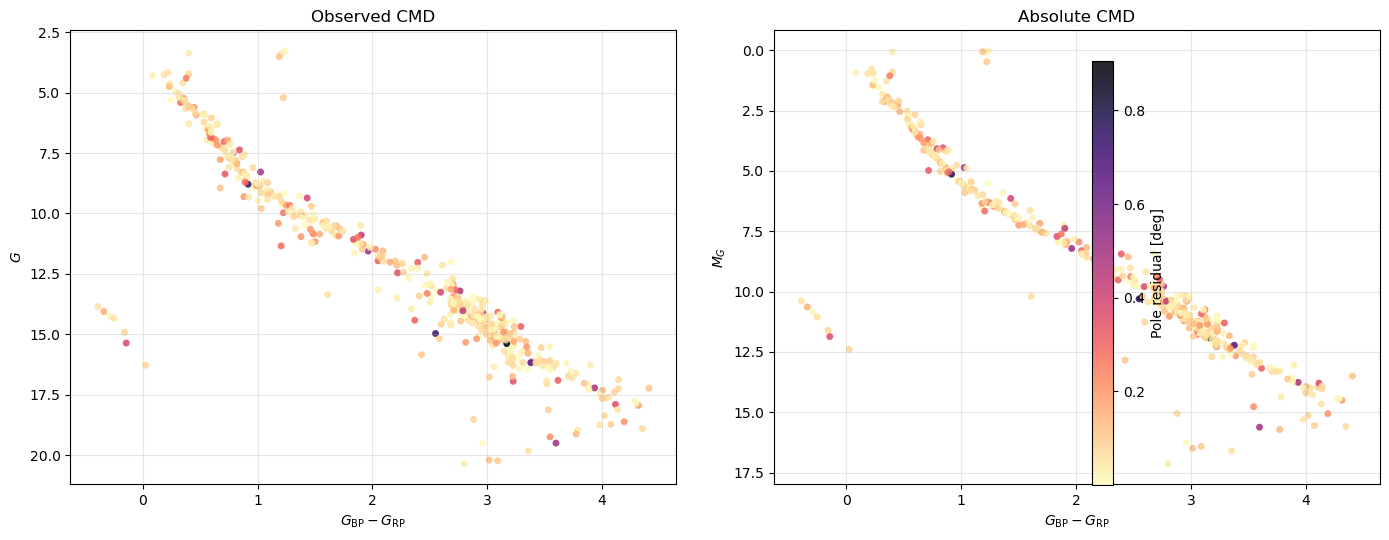


Returned objects
summary_df : global validation metrics
df_diag    : star-by-star diagnostic table
boot_df    : bootstrap apex table


In [142]:
summary_df, df_diag, boot_df = show_cluster_validation_products_icrs(
    result_hyades_semisintetico_apex_solar["cluster_result"],
    bootstrap_n=500,
)

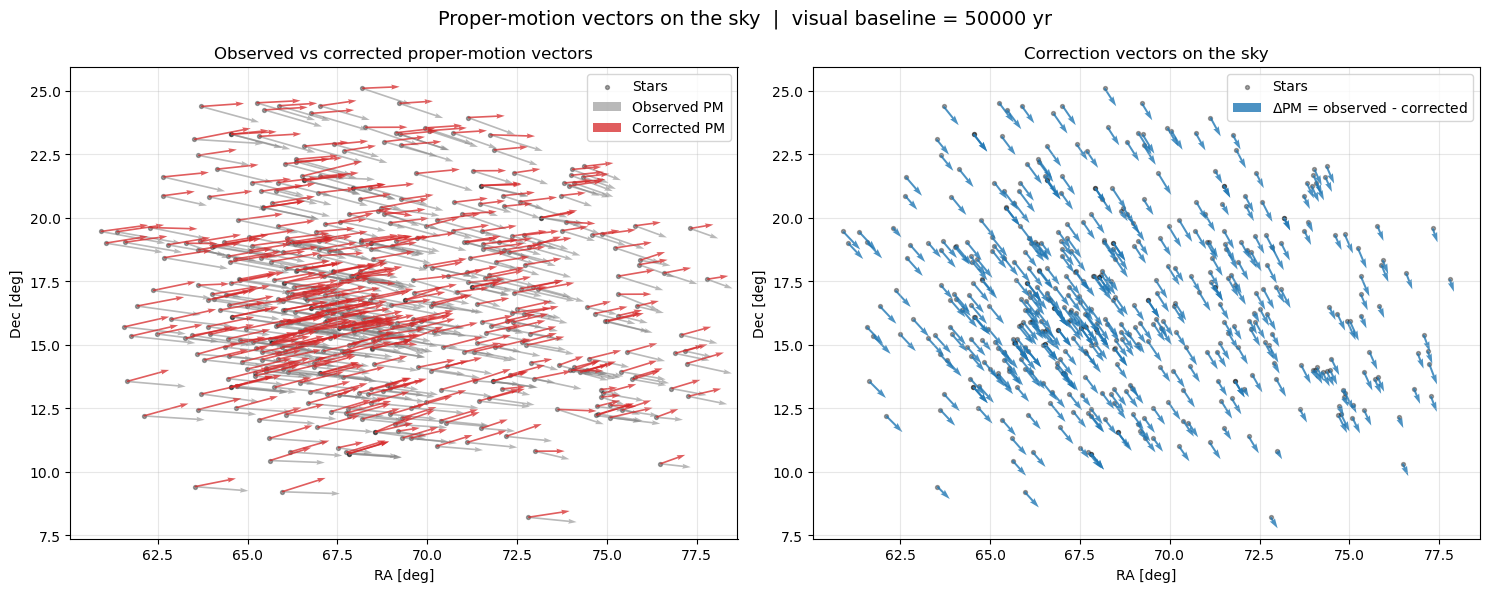

In [143]:
plot_pm_vectors_on_sky(
    result_hyades_classic_solar["data"],
    ra_col="ra",
    dec_col="dec",
    pmra_col="pmra",
    pmdec_col="pmdec",
    pmra_corr_col="pmra_corr",
    pmdec_corr_col="pmdec_corr",
    years=50000,
    max_stars=1000,
    random_state=42,
    figsize=(15, 6),
    title="Proper-motion vectors on the sky",
    save_path=None,
)

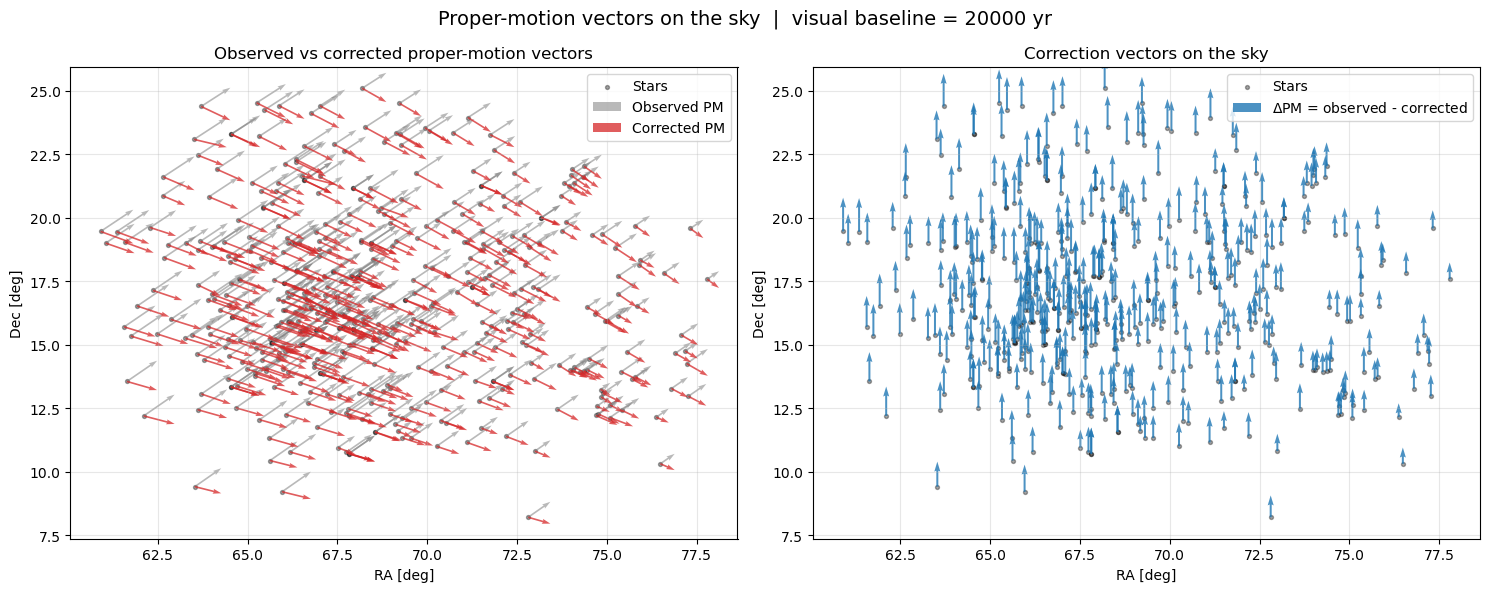

In [144]:
result_hyades_classic_solar["data"]["pmra_solar"] =  result_hyades_classic_solar["data"]["pmra"] - result_hyades_classic_solar["data"]["d_pmra_corr"]
result_hyades_classic_solar["data"]["pmdec_solar"] =  result_hyades_classic_solar["data"]["pmdec"] - result_hyades_classic_solar["data"]["d_pmdec_corr"]
plot_pm_vectors_on_sky(
    result_hyades_classic_solar["data"],
    ra_col="ra",
    dec_col="dec",
    pmra_col="pmra_solar",
    pmdec_col="pmra_solar",
    pmra_corr_col="pmra_solar",
    pmdec_corr_col="pmdec_solar",
    years=20000,
    max_stars=1000,
    random_state=42,
    figsize=(15, 6),
    title="Proper-motion vectors on the sky",
    save_path=None,
)